In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import category_encoders as ce 
import warnings
warnings.filterwarnings('ignore')


In [6]:
df= pd.read_csv('Main_file.csv')

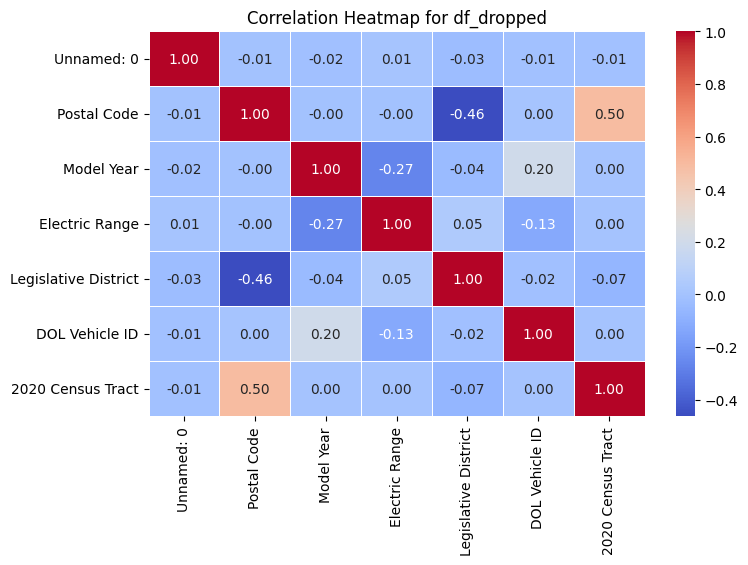

In [4]:
# 1. Calculate the correlation matrix
# Note: numeric_only=True ensures we only calculate correlation for numbers
corr_matrix = df.corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(8, 5))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # Shows the numbers in the cells
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative)
            fmt=".2f",        # Rounds numbers to 2 decimal places
            linewidths=0.5)   # Adds thin lines between cells for clarity

# 4. Add a title and show the plot
plt.title('Correlation Heatmap for df_dropped')
plt.show()

Drop na values and non important integer columns

In [18]:
df.isna().sum()

Unnamed: 0                                             0
VIN (1-10)                                             0
County                                                 8
City                                                   8
State                                                  0
Postal Code                                            8
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Legislative District                                 284
DOL Vehicle ID                                         0
Vehicle Location                                      15
Electric Utility                                       8
2020 Census Tract                                      8
dtype: int64

In [25]:
df_dropped = df.dropna()

In [26]:
df_dropped.drop(['Unnamed: 0', 'Postal Code', '2020 Census Tract'],axis=1, inplace=True)

Feature Construction


In [27]:
from datetime import datetime

# Assuming 'df_dropped' is your original dataframe with the columns you listed

# 1. VEHICLE AGE (Technological/Battery Vintage)
# Newer EVs have significantly improved battery density and management systems
current_year = datetime.now().year
df_dropped['Vehicle_Age'] = current_year - df_dropped['Model Year']

# 2. GEOGRAPHIC CLUSTERING (Urban Hubs / Infrastructure Proxy)
# Large cities often have better charging networks, influencing the choice of higher-range EVs
city_counts = df_dropped['City'].value_counts(normalize=True)
# Define "Urban Hubs" as cities in the top 10% of vehicle registrations
urban_threshold = city_counts.quantile(0.9)
urban_cities = city_counts[city_counts >= urban_threshold].index
df_dropped['Is_Urban_Hub'] = df_dropped['City'].isin(urban_cities).astype(int)

# 3. INTERACTION TERMS (Type vs. Year)
# Create a binary flag for PHEV vs BEV
df_dropped['Is_PHEV'] = df_dropped['Electric Vehicle Type'].str.contains('Plug-in Hybrid', case=False).astype(int)

# Create the interaction: Does the effect of 'Model Year' differ by 'Vehicle Type'?
# This captures how battery tech improved differently for Hybrids vs Full Electric
df_dropped['Type_Year_Interaction'] = df_dropped['Is_PHEV'] * df_dropped['Model Year']

print("New Features Constructed:")
print(df_dropped[['Vehicle_Age', 'Is_Urban_Hub', 'Type_Year_Interaction']].head())

New Features Constructed:
   Vehicle_Age  Is_Urban_Hub  Type_Year_Interaction
0           14             0                      0
1            8             1                      0
2            1             1                   2025
3           11             0                      0
4           11             1                      0


In [28]:
# Returns a list of column names that are 'object' or 'category'
cols_cat = df_dropped.select_dtypes(include=['object', 'category']).columns.tolist()

print(cols_cat)
for _ in cols_cat:
    print(_,df[_].nunique())

['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Vehicle Location', 'Electric Utility']
VIN (1-10) 8219
County 172
City 660
State 48
Make 36
Model 105
Electric Vehicle Type 2
Clean Alternative Fuel Vehicle (CAFV) Eligibility 2
Vehicle Location 791
Electric Utility 73


Do feature encoding

In [29]:
# 1. Define Column Strategies based on your data analysis
# Numeric columns will be passed through automatically
target_variable = 'Electric Range'

# High Cardinality (>100 unique): Target Encoding
high_card_cols = ['City', 'Model', 'Vehicle Location', 'County', 'VIN (1-10)']

# Medium Cardinality (30-100 unique): Binary Encoding (keeps column count low)
med_card_cols = ['Make', 'Electric Utility']

# Low Cardinality (2-10 unique): One-Hot Encoding
low_card_cols = ['Electric Vehicle Type']

# 2. Train-Test Split (Crucial to do this BEFORE fitting encoders)
X = df_dropped.drop(columns=[target_variable, 'State', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility']) # Dropping State as we discussed
y = df_dropped[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

# 3. Create the ColumnTransformer
# This object 'learns' the mapping for each group of columns
preprocessor = ColumnTransformer(
    transformers=[
        # Target Encoding: Learns the mean of 'Electric Range' for each category
        ('target_enc', ce.TargetEncoder(), high_card_cols),
        
        # Binary Encoding: 36 'Makes' will become ~6 columns instead of 36
        ('binary_enc', ce.BinaryEncoder(), med_card_cols),
        
        # One-Hot Encoding: Standard 0/1 columns
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False,drop='first'), low_card_cols)
    ],
    remainder='passthrough' # CRITICAL: Keeps all numeric columns as they are
)

# 4. Fit and Transform
# Fit on Training data (calculates means, binary bits, etc.)
X_train_encoded = preprocessor.fit_transform(X_train, y_train)

# Transform Test data (uses the 'memory' from X_train)
X_test_encoded = preprocessor.transform(X_test)

# 5. Convert back to DataFrame for readability
# Get feature names from the transformer
column_names = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_encoded, columns=column_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_encoded, columns=column_names, index=X_test.index)

# Preview the results
print(f"Original columns: {X_train.shape[1]}")
print(f"Encoded columns: {X_train_final.shape[1]}")

Original columns: 15
Encoded columns: 26


In [30]:


# 1. Join X and y for the Training set
train_full = X_train_final.copy()
train_full['Electric Range'] = y_train
train_full['Split'] = 'Train'

# 2. Join X and y for the Test set
test_full = X_test_final.copy()
test_full['Electric Range'] = y_test
test_full['Split'] = 'Test'

# 3. Stack them into one master DataFrame
df_combined = pd.concat([train_full, test_full], axis=0)

# 4. Optional: Reset index if you want a clean 0 to N count
# df_combined = df_combined.reset_index(drop=True)

print(f"Combined DataFrame Shape: {df_combined.shape}")
print(df_combined['Split'].value_counts())

Combined DataFrame Shape: (101541, 28)
Split
Train    81232
Test     20309
Name: count, dtype: int64


Remove less contributing columns

In [59]:
X_train_R =  X_train_final.drop(['binary_enc__Electric Utility_0', 'binary_enc__Electric Utility_1',
       'binary_enc__Electric Utility_2', 'binary_enc__Electric Utility_3',
       'binary_enc__Electric Utility_4',
       'binary_enc__Electric Utility_6'],axis=1)
X_test_R =  X_test_final.drop(['binary_enc__Electric Utility_0', 'binary_enc__Electric Utility_1',
       'binary_enc__Electric Utility_2', 'binary_enc__Electric Utility_3',
       'binary_enc__Electric Utility_4',
       'binary_enc__Electric Utility_6'],axis=1)


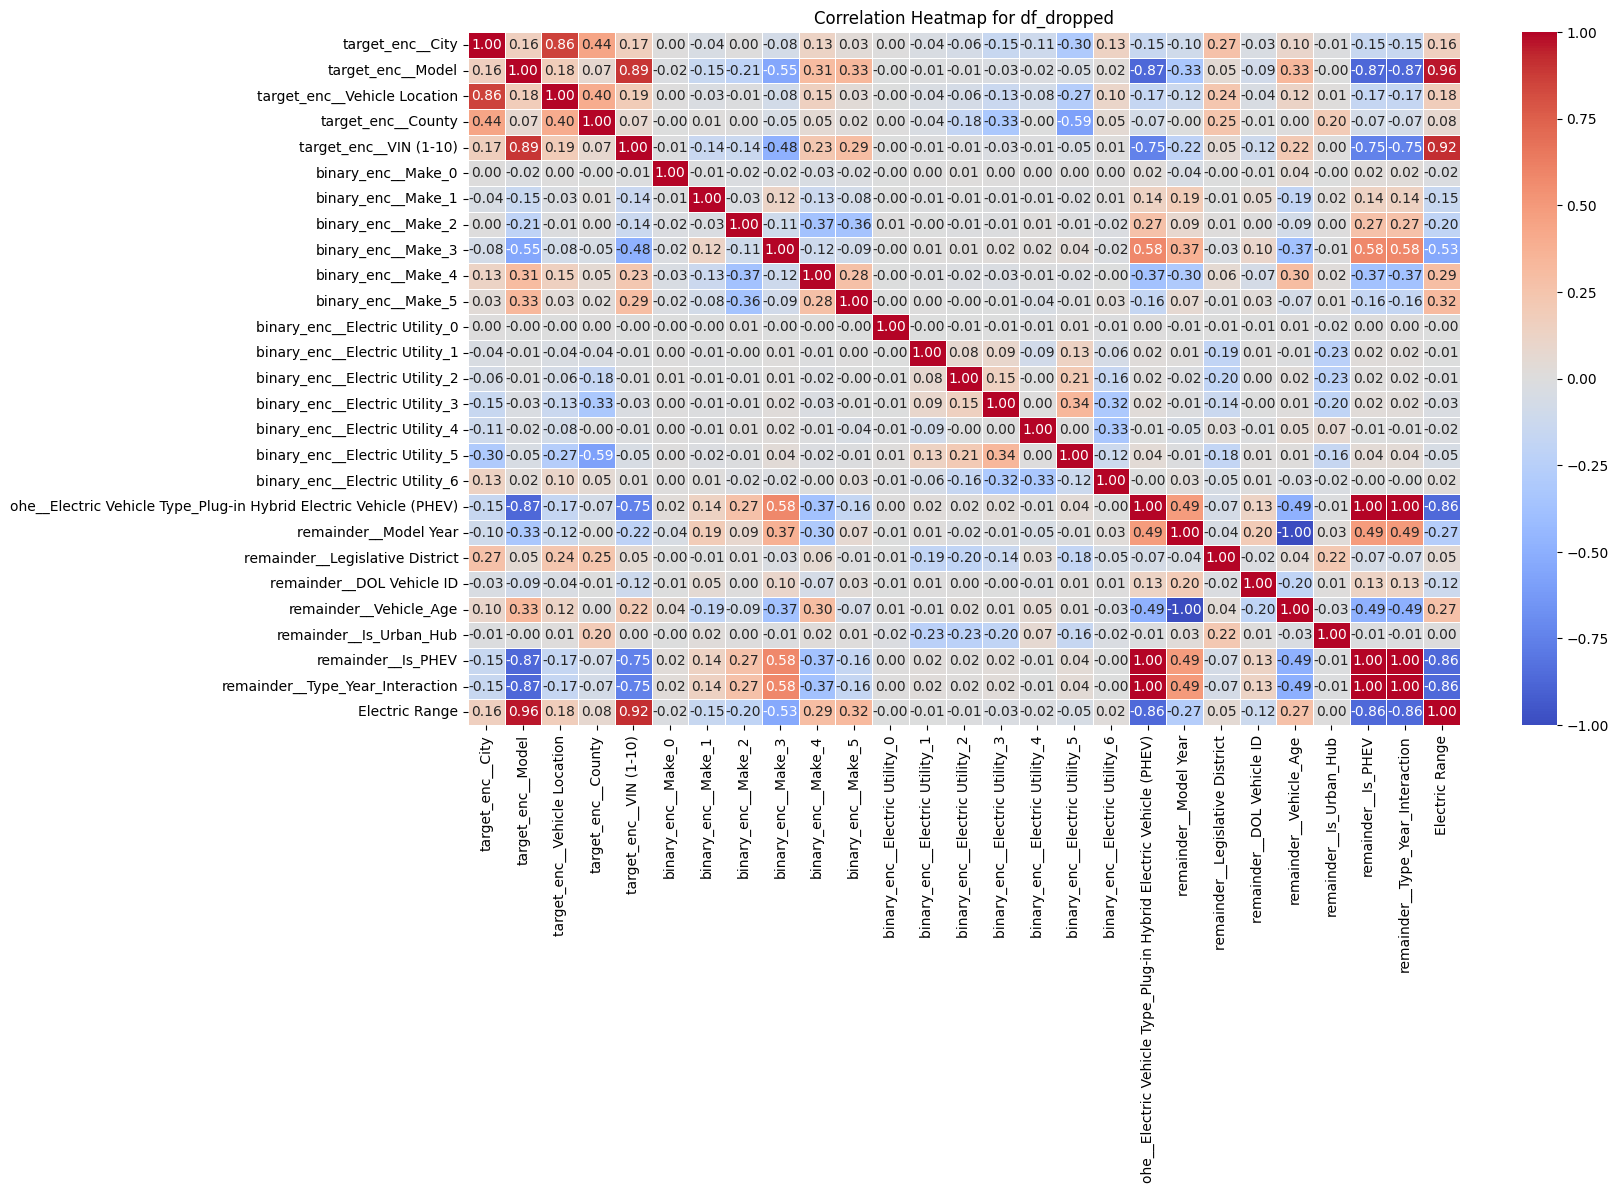

In [33]:
corr_matrix = df_combined.corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(16, 9))

# 3. Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=0.5)   

# 4. Add a title and show the plot
plt.title('Correlation Heatmap for df_dropped')
plt.show()

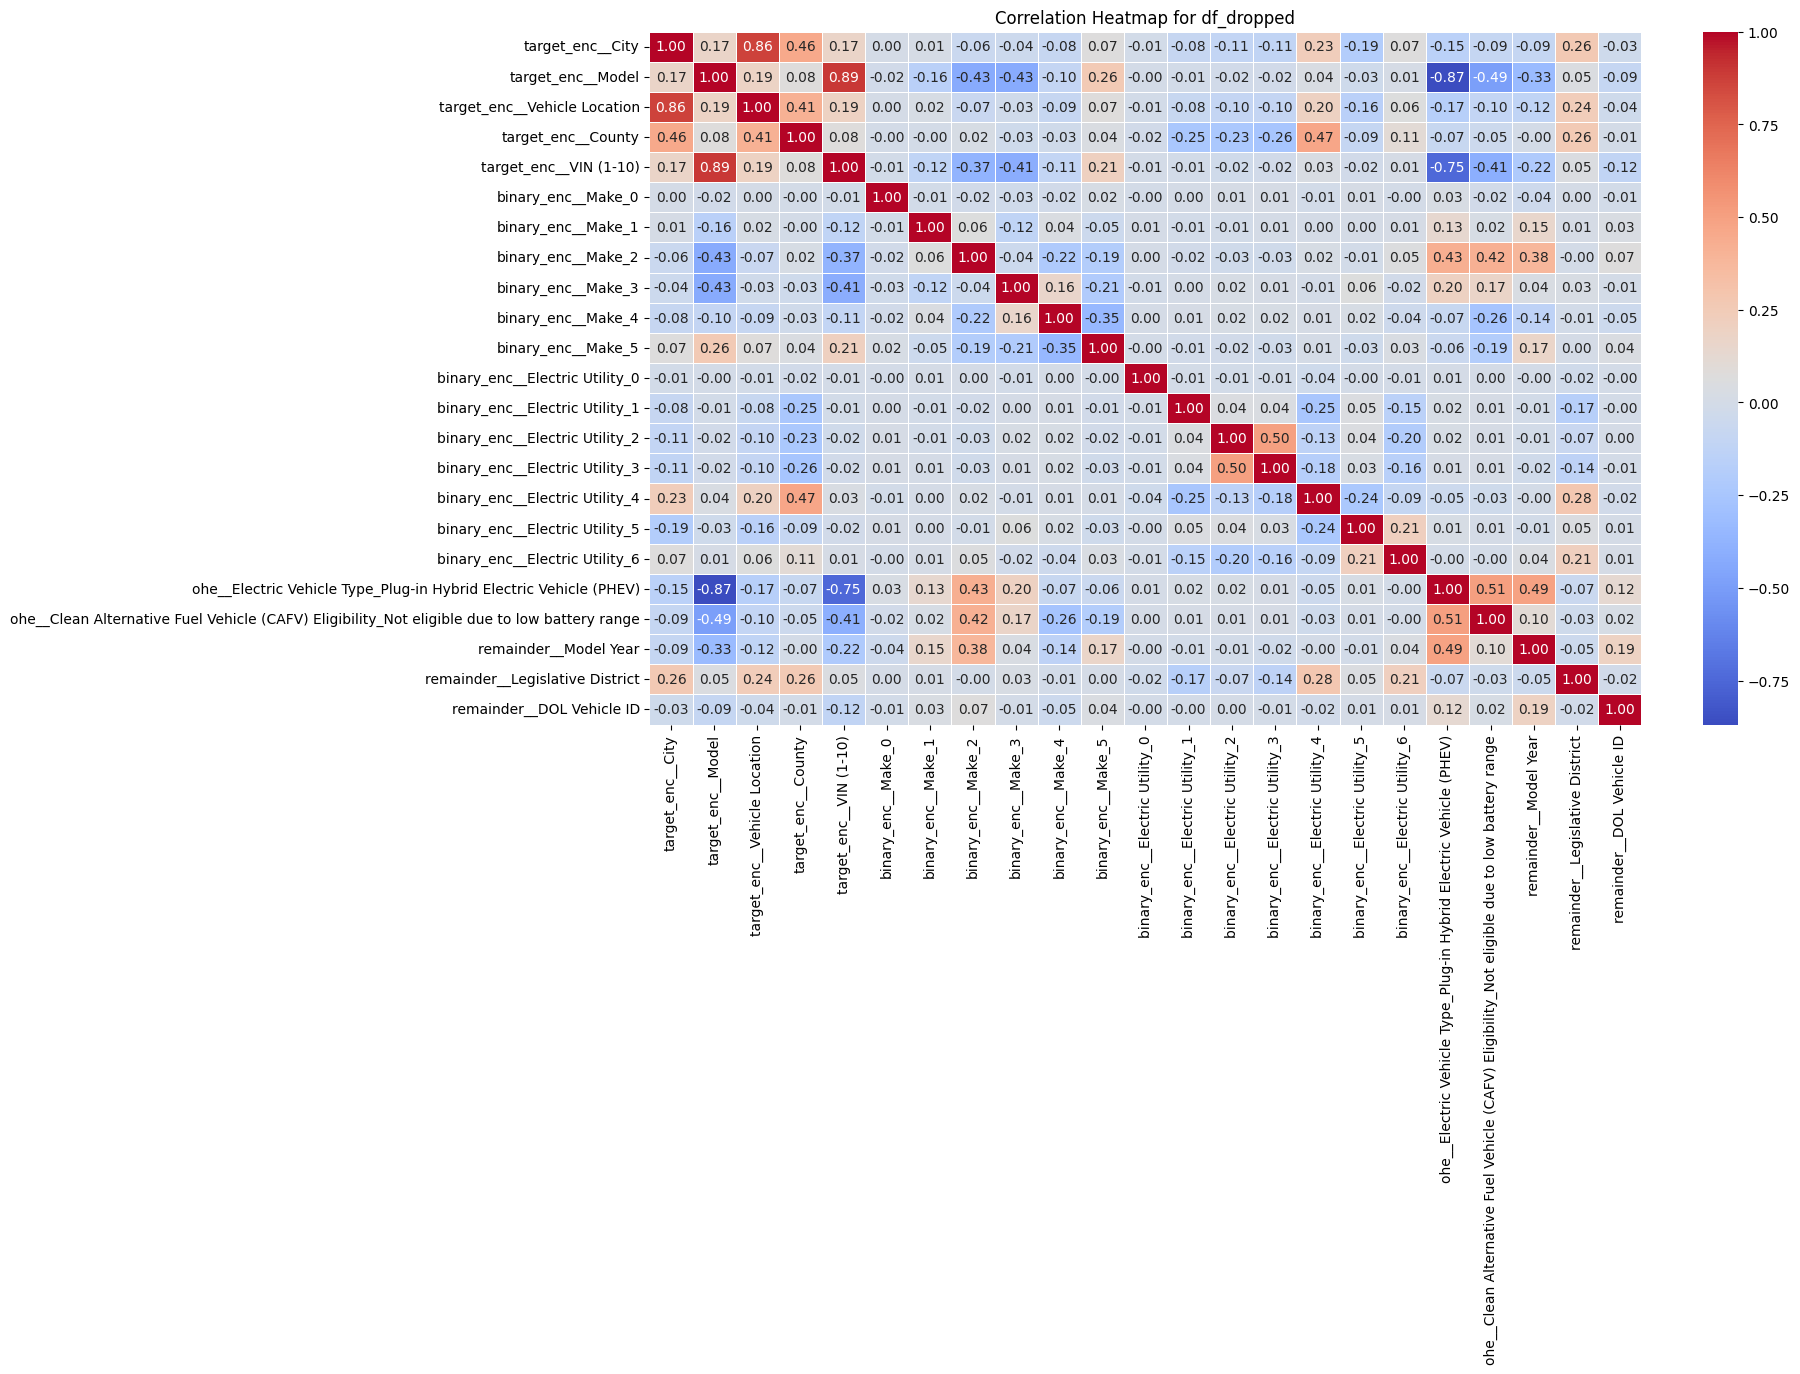

In [27]:
corr_matrix = X_train_final.corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(16, 9))

# 3. Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=0.5)   

# 4. Add a title and show the plot
plt.title('Correlation Heatmap for df_dropped')
plt.show()

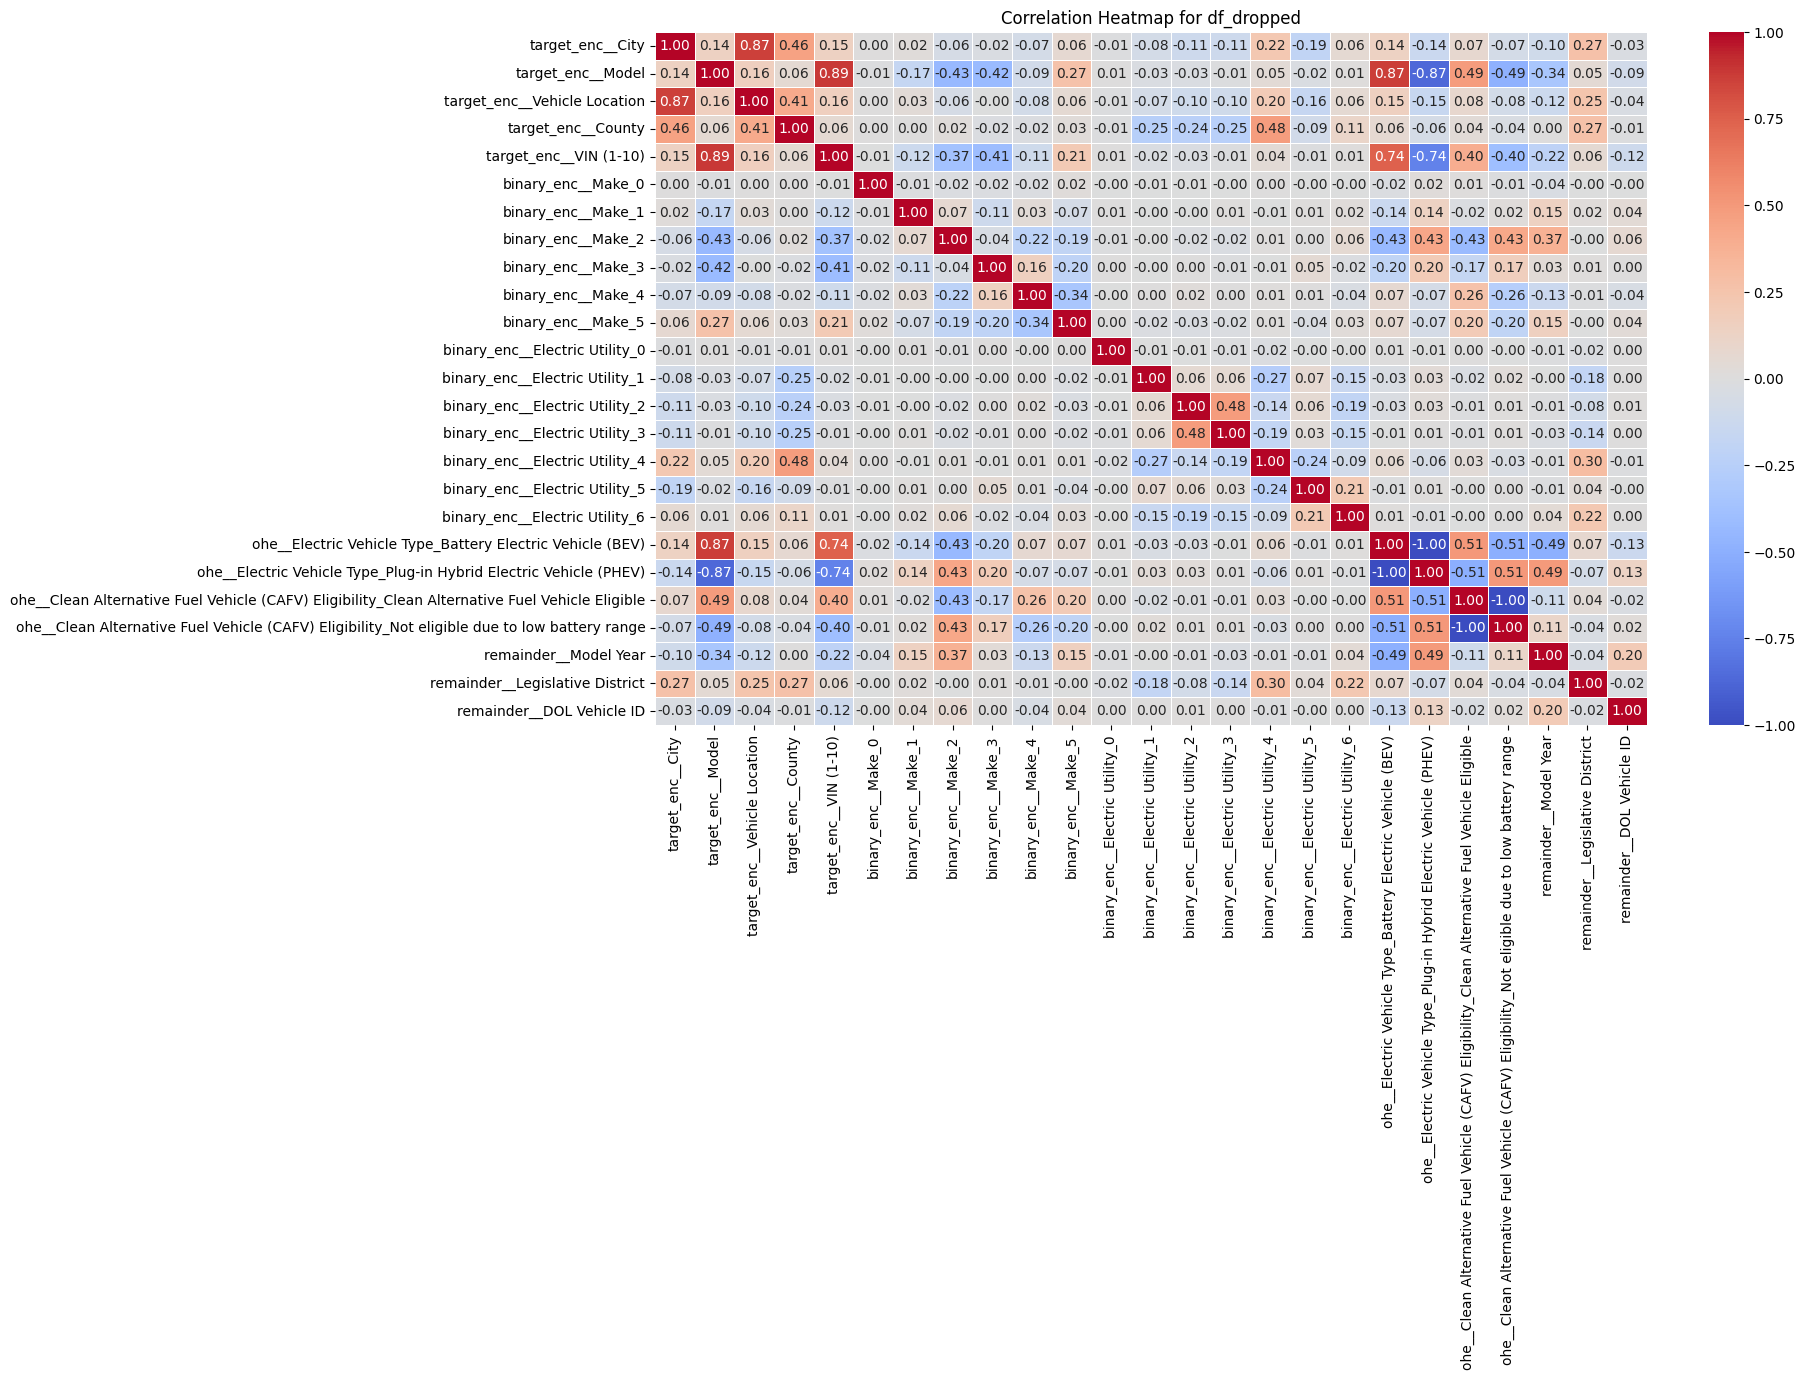

In [23]:
# 1. Calculate the correlation matrix
# Note: numeric_only=True ensures we only calculate correlation for numbers
corr_matrix = X_test_final.corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(16, 9))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # Shows the numbers in the cells
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative)
            fmt=".2f",        # Rounds numbers to 2 decimal places
            linewidths=0.5)   # Adds thin lines between cells for clarity

# 4. Add a title and show the plot
plt.title('Correlation Heatmap for df_dropped')
plt.show()

In [32]:
# 1. Define Column Strategies
target_variable = 'Electric Range'

# High Cardinality: Now using Frequency (Count) Encoding
high_card_cols = ['City', 'Model', 'Vehicle Location', 'County', 'VIN (1-10)']

# Medium Cardinality: Binary Encoding
med_card_cols = ['Make', 'Electric Utility']

# Low Cardinality: One-Hot Encoding
low_card_cols = ['Electric Vehicle Type']

# 2. Train-Test Split
X = df_dropped.drop(columns=[target_variable, 'State', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
y = df_dropped[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

# 3. Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Frequency Encoding: Replaces category with its frequency count
        # Setting return_df=True is handled internally by ColumnTransformer
        ('freq_enc', ce.CountEncoder(normalize=True), high_card_cols), 
        
        # Binary Encoding
        ('binary_enc', ce.BinaryEncoder(), med_card_cols),
        
        # One-Hot Encoding
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), low_card_cols)
    ],
    remainder='passthrough' 
)

# 4. Fit and Transform
# Note: CountEncoder doesn't strictly need 'y_train', but we pass it for consistency
X_train_encoded = preprocessor.fit_transform(X_train, y_train)
X_test_encoded = preprocessor.transform(X_test)

# 5. Convert back to DataFrame
column_names = preprocessor.get_feature_names_out()

X_train_final_2 = pd.DataFrame(X_train_encoded, columns=column_names, index=X_train.index)
X_test_final_2 = pd.DataFrame(X_test_encoded, columns=column_names, index=X_test.index)

# Preview
print(f"Original columns: {X_train.shape[1]}")
print(f"Encoded columns: {X_train_final_2.shape[1]}")

Original columns: 15
Encoded columns: 26


In [34]:


# 1. Join X and y for the Training set
train_full = X_train_final_2.copy()
train_full['Electric Range'] = y_train
train_full['Split'] = 'Train'

# 2. Join X and y for the Test set
test_full = X_test_final_2.copy()
test_full['Electric Range'] = y_test
test_full['Split'] = 'Test'

# 3. Stack them into one master DataFrame
df_combined = pd.concat([train_full, test_full], axis=0)

# 4. Optional: Reset index if you want a clean 0 to N count
# df_combined = df_combined.reset_index(drop=True)

print(f"Combined DataFrame Shape: {df_combined.shape}")
print(df_combined['Split'].value_counts())

Combined DataFrame Shape: (101541, 28)
Split
Train    81232
Test     20309
Name: count, dtype: int64


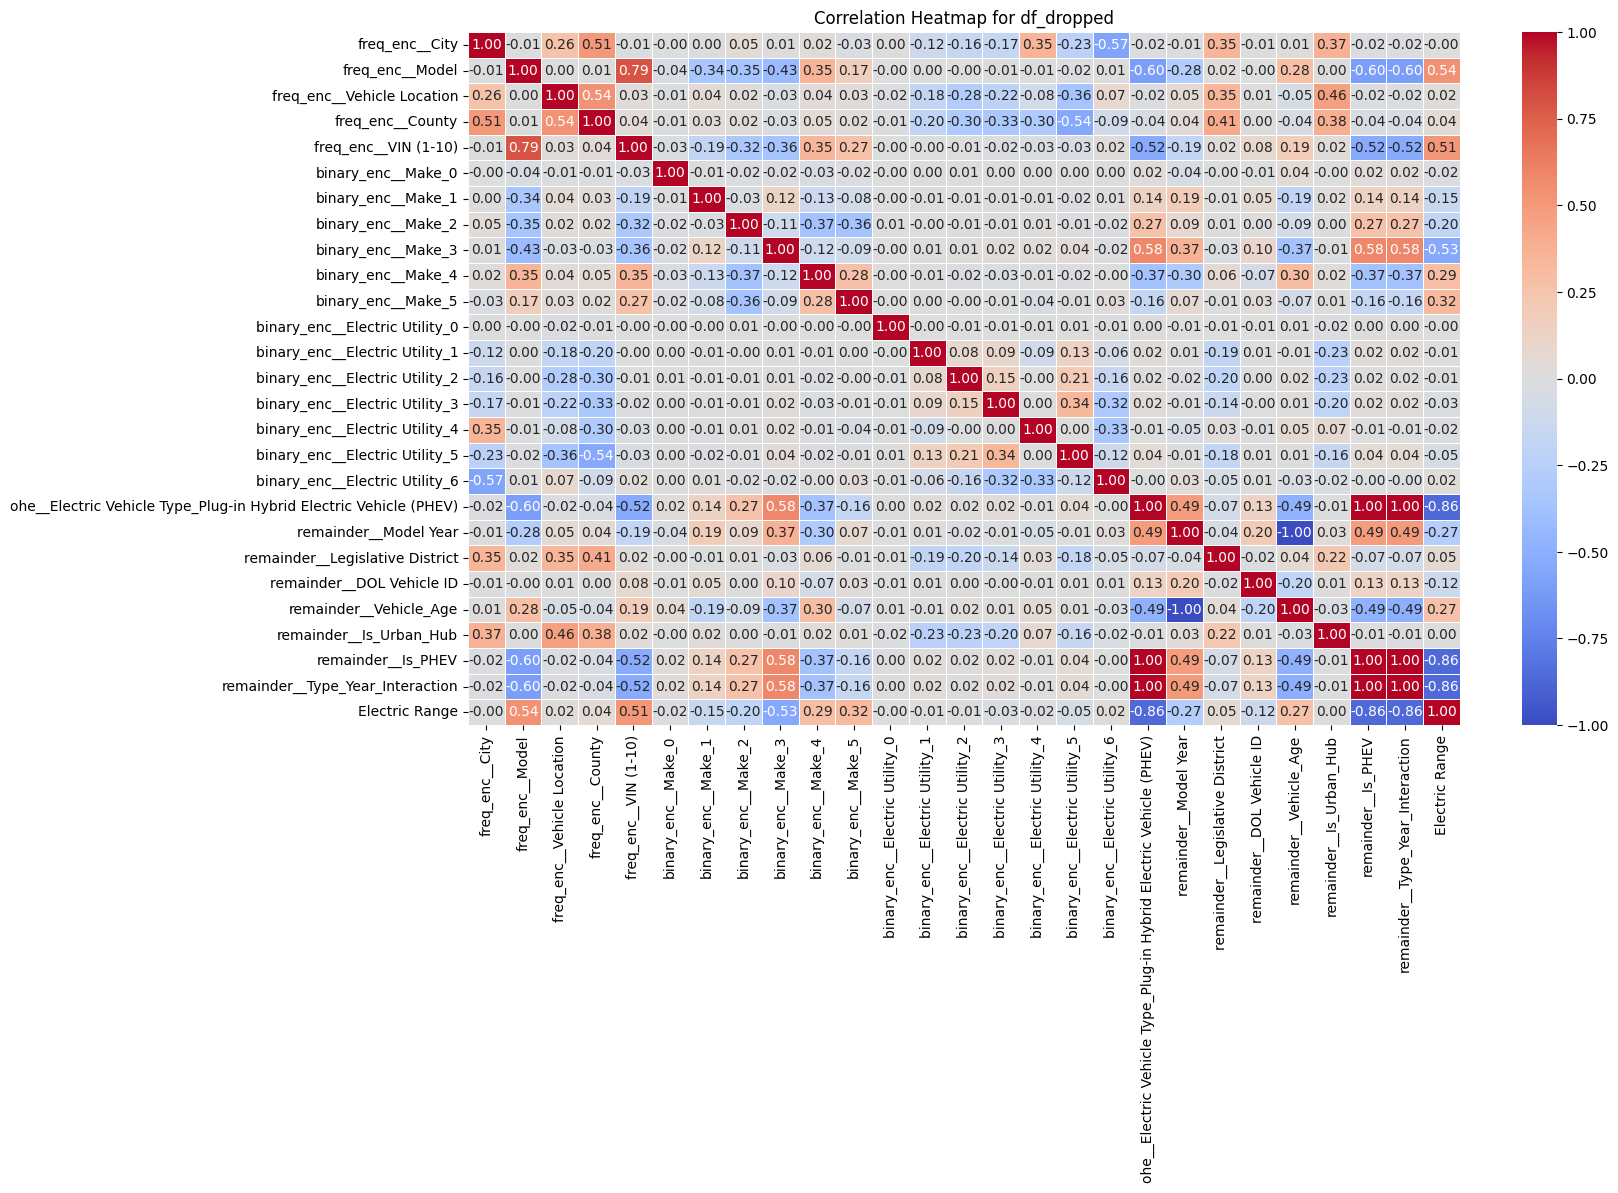

In [35]:
corr_matrix = df_combined.corr(numeric_only=True)

# 2. Set up the matplotlib figure size
plt.figure(figsize=(16, 9))

# 3. Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=0.5)   

# 4. Add a title and show the plot
plt.title('Correlation Heatmap for df_dropped')
plt.show()

Due to frequency encoding the problem of multicollinearity is not occuring. 

Columns to drop due to less correlation with target column
'binary_enc__Electric Utility_0', 'binary_enc__Electric Utility_1',
       'binary_enc__Electric Utility_2', 'binary_enc__Electric Utility_3',
       'binary_enc__Electric Utility_4', 'binary_enc__Electric Utility_5',
       'binary_enc__Electric Utility_6'

In [37]:
X_train_R =  X_train_final_2.drop(['binary_enc__Electric Utility_0', 'binary_enc__Electric Utility_1',
       'binary_enc__Electric Utility_2', 'binary_enc__Electric Utility_3',
       'binary_enc__Electric Utility_4','binary_enc__Electric Utility_5',
       'binary_enc__Electric Utility_6'],axis=1)
X_test_R =  X_test_final_2.drop(['binary_enc__Electric Utility_0', 'binary_enc__Electric Utility_1',
       'binary_enc__Electric Utility_2', 'binary_enc__Electric Utility_3',
       'binary_enc__Electric Utility_4','binary_enc__Electric Utility_5',
       'binary_enc__Electric Utility_6'],axis=1)


remainder__DOL Vehicle ID	is a unique for all rows so drop it too

In [41]:
X_train_R.drop('remainder__DOL Vehicle ID',axis=1,inplace=True)
X_test_R.drop('remainder__DOL Vehicle ID',axis=1,inplace=True)

In [42]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_R, y_train)

# 5. Evaluation Metrics
y_pred = model.predict(X_test_R)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")


RMSE: 2.25
R2 Score: 0.9995


In [43]:

# 1. Merge and Export Training Set
# We join X_train_R and y_train along the columns (axis=1)
training_set = pd.concat([X_train_R, y_train], axis=1)
training_set.to_csv('Training_set.csv', index=False)

# 2. Merge and Export Testing Set
# We join X_test_R and y_test along the columns (axis=1)
testing_set = pd.concat([X_test_R, y_test], axis=1)
testing_set.to_csv('Testing_set.csv', index=False)

print("Files 'Training_set.csv' and 'Testing_set.csv' have been created.")

Files 'Training_set.csv' and 'Testing_set.csv' have been created.
